In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

In [2]:
def fnormal1var(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2))

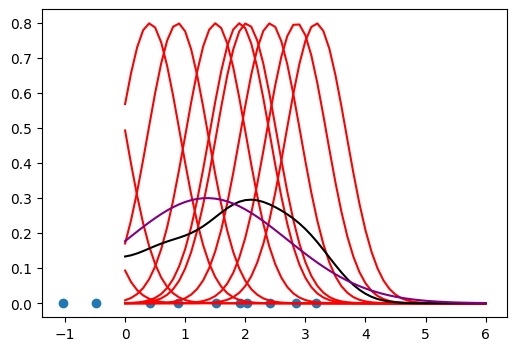

In [3]:
N1 = 10
xc = np.random.normal(loc=2, scale = 1, size = (N1,1))

plt.figure(figsize=(6,4))

plt.scatter(x=xc, y = np.zeros_like(xc))

xrange = np.arange(0,6.1,0.1)

fall = np.zeros_like(xrange)

for x in xc:

    yrange = fnormal1var(xrange, x, 0.5)

    plt.plot(xrange,yrange, color = 'red')

    fall += yrange

fall = fall/N1
plt.plot(xrange, fall, color = 'black')

mygauss = fnormal1var(xrange, np.mean(xc), np.std(xc))
plt.plot(xrange, mygauss, color = 'purple')
plt.show()

## Dados bimodais

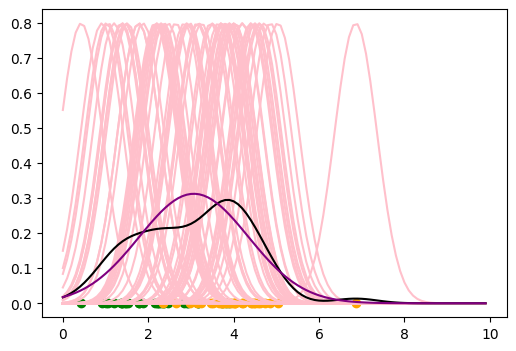

In [6]:
N1 = 30
xc1 = np.random.normal(loc=2, scale = 1, size = (N1,1))

N1 = 30
xc2 = np.random.normal(loc=4, scale = 1, size = (N1,1))

plt.figure(figsize=(6,4))

plt.scatter(x=xc1, y = np.zeros_like(xc1), color = 'green')
plt.scatter(x=xc2, y = np.zeros_like(xc2), color = 'orange')

xrange = np.arange(0,10,0.1)
xall = np.vstack((xc1,xc2))
fall = np.zeros_like(xrange)

for x in xall:

    yrange = fnormal1var(xrange, x, 0.5)

    plt.plot(xrange,yrange, color = 'pink')

    fall += yrange

fall = fall/(2*N1)
plt.plot(xrange, fall, color = 'black')

mygauss = fnormal1var(xrange, np.mean(xall), np.std(xall))
plt.plot(xrange, mygauss, color = 'purple')
plt.show()

In [13]:
def fnormal1var(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

N1 = 30
xc1 = np.random.normal(loc=2, scale=1, size=(N1, 1))
xc2 = np.random.normal(loc=4, scale=1, size=(N1, 1))

xrange = np.arange(0, 8, 0.1)
xall = np.vstack((xc1, xc2))
fall = np.zeros_like(xrange)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=xc1.flatten(), y=np.zeros_like(xc1).flatten(),
    mode='markers', name='xc1', marker=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=xc2.flatten(), y=np.zeros_like(xc2).flatten(),
    mode='markers', name='xc2', marker=dict(color='orange')
))

for x in xall:
    yrange = fnormal1var(xrange, x, 0.5)
    fig.add_trace(go.Scatter(
        x=xrange, y=yrange,
        mode='lines', line=dict(color='pink', width=1),
        opacity=0.3, showlegend=False
    ))
    fall += yrange

fall = fall / (2 * N1)
fig.add_trace(go.Scatter(
    x=xrange, y=fall,
    mode='lines', line=dict(color='black', width=2),
    name='Média densidades'
))

mygauss = fnormal1var(xrange, np.mean(xall), np.std(xall))
fig.add_trace(go.Scatter(
    x=xrange, y=mygauss,
    mode='lines', line=dict(color='purple', width=2, dash='dot'),
    name='Gauss única'
))

fig.update_layout(
    title="Distribuições Normais Interativas",
    xaxis_title="x",
    yaxis_title="Densidade",
    template="plotly_white"
)

fig.show()


## KDE Multivariado

In [18]:
def pdf(x, mu, sigma, n):
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

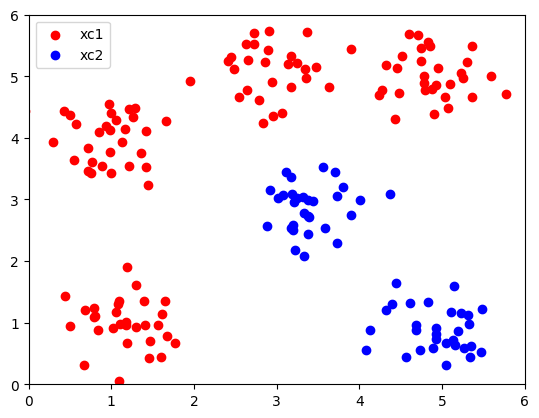

In [19]:
N = 30
NC1 = N * 4

m1 = np.array([1, 1])
m2 = np.array([1, 4])
m5 = np.array([3, 5])
m3 = np.array([5, 5])
m4 = np.array([3.5, 3])
m6 = np.array([5, 1])

sig = 0.4

xc1 = np.random.normal(scale=sig, size=(N, 2)) + m1
xc1b = np.random.normal(scale=sig, size=(N, 2)) + m2
xc1c = np.random.normal(scale=sig, size=(N, 2)) + m5
xc1d = np.random.normal(scale=sig, size=(N, 2)) + m3

xc2 = np.random.normal(scale=sig, size=(N, 2)) + m4
xc2b = np.random.normal(scale=sig, size=(N, 2)) + m6

xc1 = np.vstack([xc1, xc1b, xc1c, xc1d])
xc2 = np.vstack([xc2, xc2b])

plt.scatter(xc1[:, 0], xc1[:, 1], color='red', label='xc1')
plt.scatter(xc2[:, 0], xc2[:, 1], color='blue', label='xc2')

plt.xlim(0, 6)
plt.ylim(0, 6)
plt.xlabel("")
plt.ylabel("")
plt.legend()
plt.show()


In [22]:
import numpy as np
import plotly.graph_objects as go

N = 30

m1 = np.array([1, 1])
m2 = np.array([1, 4])
m5 = np.array([3, 5])
m3 = np.array([5, 5])
m4 = np.array([3.5, 3])
m6 = np.array([5, 1])

sig = 0.4

xc1 = np.random.normal(scale=sig, size=(N, 2)) + m1
xc1b = np.random.normal(scale=sig, size=(N, 2)) + m2
xc1c = np.random.normal(scale=sig, size=(N, 2)) + m5
xc1d = np.random.normal(scale=sig, size=(N, 2)) + m3

xc2 = np.random.normal(scale=sig, size=(N, 2)) + m4
xc2b = np.random.normal(scale=sig, size=(N, 2)) + m6

X = np.vstack([xc1, xc1b, xc1c, xc1d, xc2, xc2b])

def pdf(x, mu, sigma):
    n = len(x)
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

sigma_matrix = np.eye(2) * sig**2

x_grid = np.linspace(0, 6, 100)
y_grid = np.linspace(0, 6, 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X_grid)

for point in X:
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            Z[i, j] += pdf(np.array([X_grid[i, j], Y_grid[i, j]]), point, sigma_matrix)


fig = go.Figure(data=[go.Surface(z=Z, x=X_grid, y=Y_grid, colorscale='Viridis')])
fig.update_layout(title='Densidade de Núcleos Gaussianos', scene=dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Densidade'))
fig.show()


/tmp/ipykernel_1486/3618988335.py:30: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [23]:
fig = go.Figure(data=go.Heatmap(
    z=Z,
    x=x_grid,
    y=y_grid,
    colorscale='Viridis'
))

fig.update_layout(
    title='Mapa de Calor da Densidade de Núcleos Gaussianos',
    xaxis_title='X',
    yaxis_title='Y'
)

fig.show()

In [45]:
import numpy as np
import plotly.graph_objects as go


N = 10

m1 = np.array([1, 1])
m2 = np.array([1, 4])
m5 = np.array([3, 5])
m3 = np.array([5, 5])
m4 = np.array([3.5, 3])
m6 = np.array([5, 1])

sig = 0.4

xc1 = np.random.normal(scale=sig, size=(N, 2)) + m1
xc1b = np.random.normal(scale=sig, size=(N, 2)) + m2
xc1c = np.random.normal(scale=sig, size=(N, 2)) + m5
xc1d = np.random.normal(scale=sig, size=(N, 2)) + m3
X1 = np.vstack([xc1, xc1b, xc1c, xc1d])

xc2 = np.random.normal(scale=sig, size=(N, 2)) + m4
xc2b = np.random.normal(scale=sig, size=(N, 2)) + m6
X2 = np.vstack([xc2, xc2b])

def pdf(x, mu, sigma):
    n = len(x)
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))

sigma_matrix = np.eye(2) * sig**2

x_grid = np.linspace(0, 6, 100)
y_grid = np.linspace(0, 6, 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
Z1 = np.zeros_like(X_grid)
Z2 = np.zeros_like(X_grid)

for point in X1:
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            Z1[i, j] += pdf(np.array([X_grid[i, j], Y_grid[i, j]]), point, sigma_matrix)

for point in X2:
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            Z2[i, j] += pdf(np.array([X_grid[i, j], Y_grid[i, j]]), point, sigma_matrix)

M = np.zeros_like(X_grid)
M_value = np.zeros_like(X_grid)
P1 = len(X1)/(len(X1) + len(X2))
P2 = len(X2)/(len(X1) + len(X2))
for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            M[i, j] = 1 if Z1[i, j]*P1 > Z2[i, j]*P2 else 2
            M[i, j] = Z1[i, j]*P1 if (Z1[i, j]*P1)/(Z2[i, j]*P2) > 1 else Z2[i, j]*P2
fig = go.Figure()

# fig.add_trace(go.Surface(z=Z1, x=X_grid, y=Y_grid, colorscale='Reds', opacity=0.7, name='Classe 1'))
# fig.add_trace(go.Surface(z=Z2, x=X_grid, y=Y_grid, colorscale='Blues', opacity=0.7, name='Classe 2'))
fig.add_trace(go.Surface(z=M_value, x=X_grid, y=Y_grid, colorscale='Greens', opacity=0.7, name='Classe 2'))

fig.update_layout(
    title='Superfície de Densidade Separada por Classes',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Densidade'
    )
)

fig.show()


/tmp/ipykernel_1486/3124544210.py:31: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [41]:
X_grid[0]


array([0.        , 0.06060606, 0.12121212, 0.18181818, 0.24242424,
       0.3030303 , 0.36363636, 0.42424242, 0.48484848, 0.54545455,
       0.60606061, 0.66666667, 0.72727273, 0.78787879, 0.84848485,
       0.90909091, 0.96969697, 1.03030303, 1.09090909, 1.15151515,
       1.21212121, 1.27272727, 1.33333333, 1.39393939, 1.45454545,
       1.51515152, 1.57575758, 1.63636364, 1.6969697 , 1.75757576,
       1.81818182, 1.87878788, 1.93939394, 2.        , 2.06060606,
       2.12121212, 2.18181818, 2.24242424, 2.3030303 , 2.36363636,
       2.42424242, 2.48484848, 2.54545455, 2.60606061, 2.66666667,
       2.72727273, 2.78787879, 2.84848485, 2.90909091, 2.96969697,
       3.03030303, 3.09090909, 3.15151515, 3.21212121, 3.27272727,
       3.33333333, 3.39393939, 3.45454545, 3.51515152, 3.57575758,
       3.63636364, 3.6969697 , 3.75757576, 3.81818182, 3.87878788,
       3.93939394, 4.        , 4.06060606, 4.12121212, 4.18181818,
       4.24242424, 4.3030303 , 4.36363636, 4.42424242, 4.48484

In [ ]:
fig = go.Figure()
# fig.add_trace(go.Heatmap(z=Z1, x=x_grid, y=y_grid, colorscale='Reds', opacity=1, showscale=False))
# fig.add_trace(go.Heatmap(z=Z2, x=x_grid, y=y_grid, colorscale='Blues', opacity=0.5, showscale=False))

fig.add_trace(go.Heatmap(
    z=Z1,
    x=x_grid,
    y=y_grid,
    colorscale='Reds',
    zsmooth='best',
    opacity=1,
    showscale=True
))

fig.update_layout(
    title='Superfície de Densidade + Heatmap por Classe',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Densidade'
    )
)

fig.show()

In [1]:
import numpy as np

N = 30
NC1 = N * 4

m1 = np.array([1, 1])
m2 = np.array([1, 4])
m5 = np.array([3, 5])
m3 = np.array([5, 5])
m4 = np.array([3.5, 3])
m6 = np.array([5, 1])

sig = 0.4

xc1 = np.random.normal(scale=sig, size=(N, 2)) + m1
xc1b = np.random.normal(scale=sig, size=(N, 2)) + m2
xc1c = np.random.normal(scale=sig, size=(N, 2)) + m5
xc1d = np.random.normal(scale=sig, size=(N, 2)) + m3

xc2 = np.random.normal(scale=sig, size=(N, 2)) + m4
xc2b = np.random.normal(scale=sig, size=(N, 2)) + m6

xc1 = np.vstack([xc1, xc1b, xc1c, xc1d])
xc2 = np.vstack([xc2, xc2b])


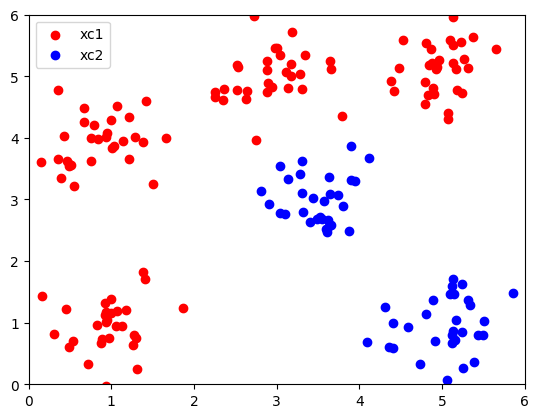

In [2]:
import matplotlib.pyplot as plt

plt.scatter(xc1[:, 0], xc1[:, 1], color='red', label='xc1')

plt.scatter(xc2[:, 0], xc2[:, 1], color='blue', label='xc2')

plt.xlim(0, 6)
plt.ylim(0, 6)
plt.xlabel("")
plt.ylabel("")

plt.legend()
plt.show()


In [8]:
def pdf(x, mu, sigma):
    n = len(x)
    const = 1 / np.sqrt(((2*np.pi)**n) * np.linalg.det(sigma))
    diff = (x - mu).reshape(-1, 1)
    expo = -0.5 * diff.T @ np.linalg.inv(sigma) @ diff
    return float(const * np.exp(expo))


    

/tmp/ipykernel_3424/3961458275.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(const * np.exp(expo))


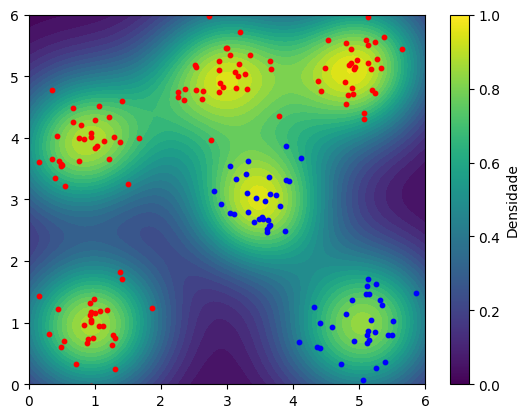

In [9]:
X = np.vstack([xc1, xc2])

sigma = np.array([[0.5, 0], [0, 0.5]]) 

x = np.linspace(0, 6, 100)
y = np.linspace(0, 6, 100)
Xgrid, Ygrid = np.meshgrid(x, y)
pos = np.dstack((Xgrid, Ygrid))

for i in range(X.shape[0]):
    mu = X[i]
    for ix in range(len(x)):
        for iy in range(len(y)):
            point = np.array([Xgrid[ix, iy], Ygrid[ix, iy]])
            Z[ix, iy] += pdf(point, mu, sigma)

plt.contourf(Xgrid, Ygrid, Z, levels=30, cmap="viridis")
plt.scatter(xc1[:,0], xc1[:,1], color='red', s=10)
plt.scatter(xc2[:,0], xc2[:,1], color='blue', s=10)
plt.colorbar(label="Densidade")
plt.xlim(0,6)
plt.ylim(0,6)
plt.show()


In [10]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=Z, x=Xgrid, y=Ygrid, colorscale="Viridis")])
fig.update_layout(
    title="Superfície de densidade (soma dos núcleos Gaussianos)",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Densidade"
    )
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed